# Exploration des données

In [56]:
import pandas as pd
import os
import matplotlib.pyplot as plt

import csv
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## Récupération et nettoyage des données

In [57]:
db = pd.read_csv("data/raw/cardio_train.csv", sep=";")

# Suppresion des lignes doublés
db = db.drop_duplicates()
# Nombre de lignes doublées supprimées
print('\nAprès suppression lignes doublées :')
print(db.info())

# Vérification de valeurs manquantes
print("\nVérification de valeurs manquantes :")
print(db.isnull().sum())


Après suppression lignes doublées :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB
None

Vérification de valeurs manquantes :
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol

## Prétraitement des données

In [58]:
# Eviter les erreurs de type de données
print("\nTypes de données avant conversion :")
print(db.dtypes)

# Changement de la variable age = nombes de jours -> nombre d'années
db["age"] = (db["age"] / 365).round().astype(int)
print("\nVariable age convertie en années :")
print(db["age"].head())

# Changement de la variable gender de 1 --> Female et 2 --> Male
"""db["gender"] = db["gender"].map({1: "Female", 2: "Male"})
print("\nVariable gender convertie en catégories :")
print(db["gender"].head())"""

# Renommage des colonnes pour plus de clarté
db.columns=['id','age','genre','taille','poids','systolic','diastolic','cholestrol','glucose','fumeur','alcool','sportif','malade']

# Enregistrement du dataset nettoyé
os.makedirs("data/clean", exist_ok=True)
try:
    db.to_csv("data/clean/cardio_train_clean.csv", index=False)
    print("\nDataset nettoyé enregistré dans data/clean/cardio_train_clean.csv")
except Exception as e:
    print(f"Erreur lors de l'enregistrement du dataset : {e}")


Types de données avant conversion :
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

Variable age convertie en années :
0    50
1    55
2    52
3    48
4    48
Name: age, dtype: int32

Dataset nettoyé enregistré dans data/clean/cardio_train_clean.csv


### Après le pré-traitement, nos données sont plus compréhensible pour le modèle qui va être utilisé.

L'âge qui était en nombre de jours a été converti en nombre d'année.
La variable gender a été modifié et tous les 0 sont renommé Female, et 1 sont renommé Male.

## Visualisations et analyses

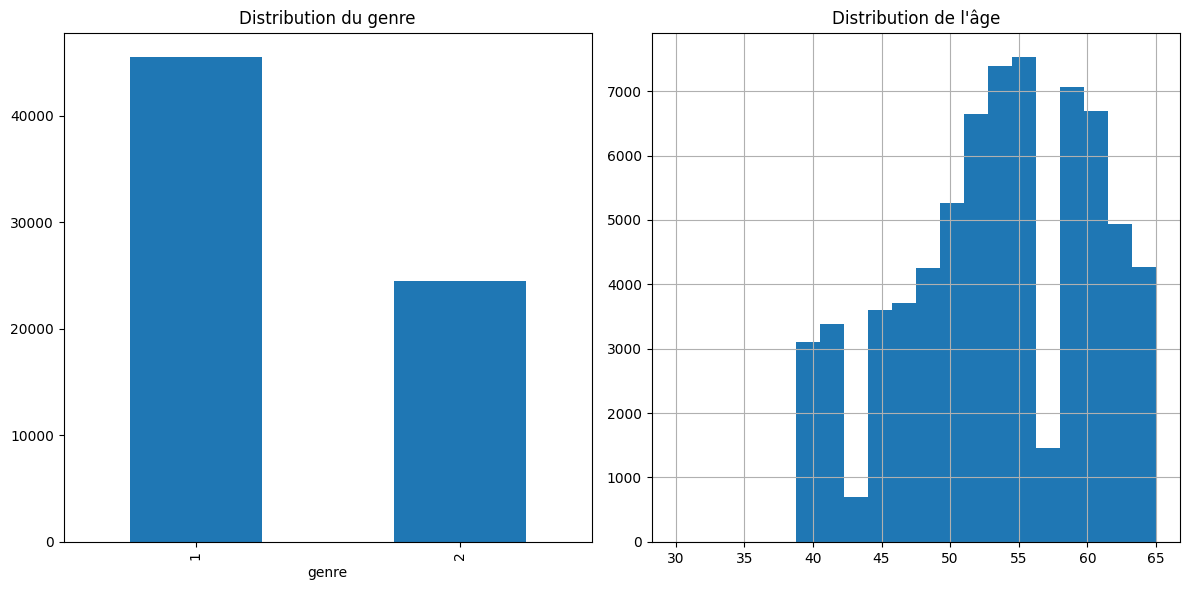

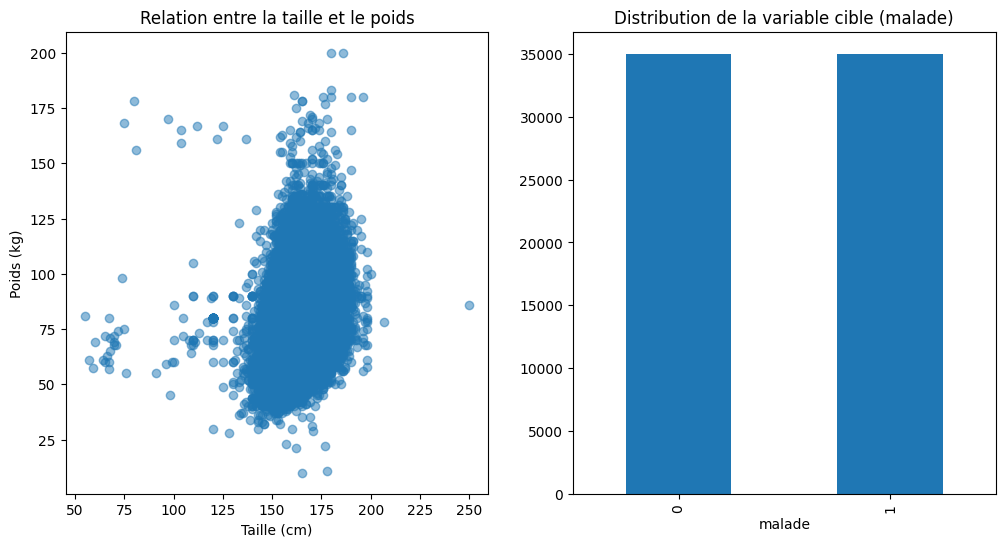

In [59]:
# Visualisation de la distribution des différentes variables (gender, age, etc.)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
db["genre"].value_counts().plot(kind="bar")
plt.title("Distribution du genre")

plt.subplot(1, 2, 2)
db["age"].hist(bins=20)
plt.title("Distribution de l'âge")
plt.tight_layout() 

# Nuage de points des height et weight
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(db["taille"], db["poids"], alpha=0.5)
plt.title("Relation entre la taille et le poids")
plt.xlabel("Taille (cm)")
plt.ylabel("Poids (kg)")

# Distribution de la variable cible (cardio)
plt.subplot(1, 2, 2)
db["malade"].value_counts().plot(kind="bar")
plt.title("Distribution de la variable cible (malade)")

plt.show()

## Régression Logistique avec bibliothèque

Dataset chargé avec succès depuis data/clean/cardio_train_clean.csv

Accuracy du modèle : 0.66

Matrice de confusion en graphique :


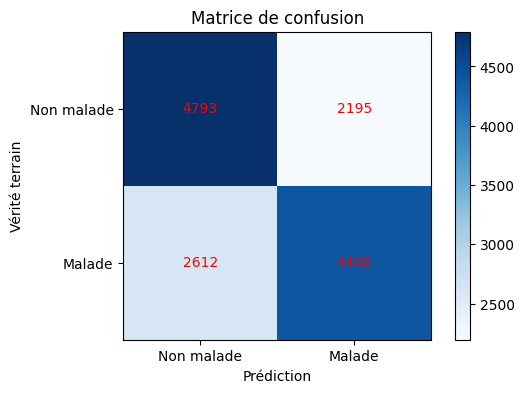

In [64]:
dataset_path = "data/clean/cardio_train_clean.csv"
try:
    db = pd.read_csv(dataset_path)
    print(f"Dataset chargé avec succès depuis {dataset_path}")
except FileNotFoundError:
    print(f"Erreur : Le fichier {dataset_path} n'a pas été trouvé.")

# Chargement des variables x et y afin de pouvoir split et trainer le modèle de régression logistique
X = db.drop("malade", axis=1)
y = db["malade"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Standardisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entraînement du modèle de régression logistique
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Prédiction et évaluation du modèle
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"\nAccuracy du modèle : {accuracy:.2f}")
print("\nMatrice de confusion en graphique :")
plt.figure(figsize=(6, 4))
plt.imshow(conf_matrix, cmap="Blues")
plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Vérité terrain")
plt.colorbar()
plt.xticks([0, 1], ["Non malade", "Malade"])
plt.yticks([0, 1], ["Non malade", "Malade"])
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center", color="red")
plt.show()

## Régression Logistique sans bibliothèque

[0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 

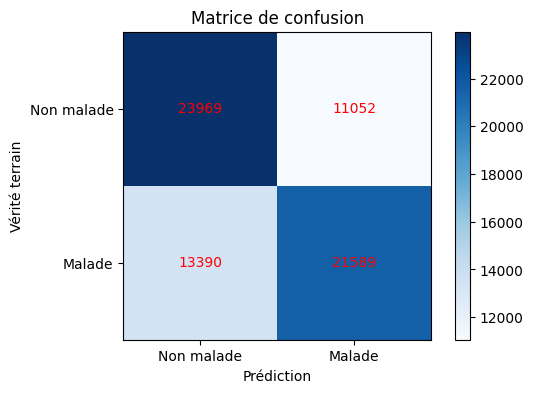

In [ ]:
def load_csv(dataset_path):
    X = []
    y = []
    
    with open(dataset_path, 'r') as file:
        reader = csv.reader(file)
        next(reader)  # skip header
        
        for row in reader:
            X.append([float(x) for x in row[:-1]])
            y.append(float(row[-1]))
    
    return np.array(X), np.array(y)


class LogisticRegression:

    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for _ in range(self.epochs):
            
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)
            
            # gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)
            
            # update
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
    
    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

    def predict(self, X):
        proba = self.predict_proba(X)
        return [1 if i > 0.5 else 0 for i in proba]
    



# Charger données
X, y = load_csv("data/clean/cardio_train_clean.csv")
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Initialiser modèle
model = LogisticRegression(lr=0.01, epochs=1000)

# Entraîner
model.fit(X, y)

# Prédictions
predictions = model.predict(X)

"""print(predictions)"""

# Accuracy
accuracy = np.mean(predictions == y)
print(f"\nAccuracy: {accuracy:.2f}")

# Matrice de confusion en graphique
conf_matrix = confusion_matrix(y, predictions)
plt.figure(figsize=(6, 4))
plt.imshow(conf_matrix, cmap="Blues")
plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Vérité terrain")
plt.colorbar()
plt.xticks([0, 1], ["Non malade", "Malade"])
plt.yticks([0, 1], ["Non malade", "Malade"])
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center", color="red")
plt.show()

## Evaluation des résultats

## Exemple concret avec Arthur